# APR Amazon 지수 — 공시 수출 앵커 검증 V4

`apr_us_amazon_keepa_query_v4.ipynb`

---

## V4 변경사항

| 항목 | 내용 |
|---|---|
| **재보간 (핵심)** | DB에 저장된 실관측 시점(`is_ffilled=0`)에서 패널을 다시 만든다. **재수집·토큰 불필요** |
| 분석창 | `ANALYSIS_MIN_DATE` 를 2023-01-01 로 앞당겨 가속 관측치 확보 |
| 톱니 진단 | 활성 ASIN 수의 진동 강도를 수치화. 지수 신뢰도의 선결 조건 |
| **점유율 지수** | Amazon 성장 ÷ 수출 성장의 누적곱. 채널 믹스 변화를 직접 측정 |
| **대기 분기** | 실적 미공시 분기의 Amazon 신호를 미리 제시. 다음 공시가 판별 시점 |
| 판정 가드레일 | 관측치·패널 규모가 기준 미달이면 "판정 유보"로 강제 |
| 차트 | 이중축 제거(양쪽 지수화), `%q` 포맷 버그 수정, 가속도 패널 추가 |

## V3.1에서 드러난 문제

첫 실행 결과가 이랬다.

```
균형패널 3개 ASIN / 가속 관측치 4개 → "신호로 사용 가능" (가속일치 100%)
```

**이 판정은 과장이다.** 동전 던지기로 4연속 맞을 확률이 6%다.
게다가 활성 ASIN 수가 40개↔5개를 오가는 톱니여서 지수 자체의 신뢰도가 낮았다.

원인은 수집 시 `FFILL_LIMIT_D=7`이었다. Keepa는 저순위 상품을 드물게 갱신하는데
7일에서 보간을 끊으니 관측 사이가 비었다. **그러나 실관측 시점은 DB에 남아 있으므로
재수집 없이 더 긴 보간으로 패널을 다시 만들 수 있다.** 그것이 V4의 1장이다.

## 이번 분석의 실제 질문

V3.1 결과에서 2026Q1에 Amazon YoY(약 180%)와 수출 YoY(179%)가 처음 수렴했다.
그 전까지 Amazon은 수출보다 5~9배 빠르게 성장했다. 두 가지 해석이 가능하다.

- **(A) 기저효과 정상화** — Amazon 기저가 0에 가까워 YoY가 부풀었고, 이제 제자리를 찾는 중
- **(B) 채널 믹스 이동** — Ulta 전점 입점(2025-08) 이후 Amazon 비중이 실제로 줄어드는 중

V4의 **점유율 지수**가 이 둘을 가른다. 지수가 1 근처에서 안정되면 (A),
계속 하락하면 (B)다. (B)라면 Amazon 단독 추적으로는 APR을 볼 수 없다.

---
**V4** | 2026-08

## 1. 사용자 입력 변수

In [1]:
# ============================================================================
# USER INPUT
# ============================================================================

TICKER          = "A278470"
DOMAIN          = "US"

# ---------- 재보간 (V4 핵심) ----------
REFILL_ENABLED  = True          # DB 실관측 시점에서 패널 재구성
REFILL_LIMIT_D  = 21            # 재보간 최대 일수 (수집 시 7일 → 21일로 확장)
REFILL_GRID     = [7, 14, 21, 30, 45]   # 커버리지 개선 효과 비교용

# ---------- 분석창 ----------
ANALYSIS_MIN_DATE = "2023-01-01"   # V3.1의 2023-10-01 → 앞당겨 가속 관측치 확보
COVERAGE_MIN    = 0.70          # 꼬리 절단 기준 (전체 최대 대비)
COVERAGE_ABS_MIN = 5            # 머리 절단 기준 (활성 ASIN 절대 하한)
TRIM_HEAD       = True
TRIM_TAIL       = True

# ---------- 균형패널 ----------
BALANCED_MIN_COVER = 0.90
BALANCED_RELAX  = [0.90, 0.80, 0.70, 0.60, 0.50]
BALANCED_MIN_N  = 3

# ---------- 지수 ----------
ALPHA           = 0.70
ALPHA_GRID      = [0.5, 0.6, 0.7, 0.8, 0.9]
PRIMARY_INDEX   = "gmv_balanced"

# ---------- 판정 가드레일 ----------
MIN_ACC_OBS     = 6             # 가속 관측치가 이보다 적으면 판정 유보
MIN_BALANCED_N  = 8             # 균형패널이 이보다 적으면 판정 유보
MAX_JAGGEDNESS  = 0.12          # 톱니 지수가 이보다 크면 판정 유보

# ---------- 검증 ----------
LAG_RANGE       = [0, 1, 2]
RESAMPLE_RULE   = "QE"
USE_YOY         = True
MIN_OBS_SIGN    = 3

# ---------- 관세청 (선택) ----------
CUSTOMS_ENABLED = False
CUSTOMS_SQL     = None
CUSTOMS_DATE_COL = "date"
CUSTOMS_VAL_COL  = "usd_amt"

# ---------- 시각화 ----------
SHOW_PLOTS      = True
FIG_W           = 14
REBASE_DATE     = None

# ---------- 테이블 ----------
TBL_ASIN_MASTER = "amazon_asin_master"
TBL_BSR_DAILY   = "amazon_bsr_daily"
TBL_TRENDS_MET  = "apr_us_trends_metrics"
TBL_APR_REV     = "apr_revenue_quarterly"


## 2. 환경 · DB 연결

In [2]:
import os
import sys
import json
import warnings
from datetime import date, datetime
from typing import Optional, Union, List, Dict, Any, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

# ============================================================================
# 경로 자동탐지 — 데스크톱 / 노트북 어디서 실행해도 DATA/ 를 찾아낸다
# ============================================================================
# 탐색 순서:
#   1) BASE_PATH_OVERRIDE (수동 지정)
#   2) 환경변수 STOCK_BASE_PATH
#   3) 현재 작업 디렉토리에서 상위로 6단계
#   4) 알려진 고정 경로
#   5) 홈 디렉토리 기반 얕은 탐색 (OneDrive / 바탕 화면 / Desktop 등)
# ----------------------------------------------------------------------------

BASE_PATH_OVERRIDE = None   # 전부 실패하면 여기에 경로를 직접 문자열로 넣으십시오

KNOWN_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

PROJECT_DIR_NAMES = ["stock_forecast", "investment_strategy", "investment"]


def _has_data(p: Optional[str]) -> bool:
    if not p:
        return False
    try:
        return os.path.isdir(os.path.join(p, "DATA"))
    except Exception:
        return False


def resolve_base_path() -> Tuple[Optional[str], List[Tuple[str, str]]]:
    """DATA/ 를 포함한 프로젝트 루트를 탐색. (경로, 시도이력) 반환."""
    tried: List[Tuple[str, str]] = []

    # (1) 수동 지정
    if BASE_PATH_OVERRIDE:
        tried.append(("override", BASE_PATH_OVERRIDE))
        if _has_data(BASE_PATH_OVERRIDE):
            return BASE_PATH_OVERRIDE, tried

    # (2) 환경변수
    envp = os.environ.get("STOCK_BASE_PATH")
    if envp:
        tried.append(("env", envp))
        if _has_data(envp):
            return envp, tried

    # (3) cwd에서 상위로 — 노트북이 프로젝트 하위 어디에 있어도 잡힌다
    cur = os.path.abspath(os.getcwd())
    for _ in range(6):
        tried.append(("cwd-up", cur))
        if _has_data(cur):
            return cur, tried
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent

    # (4) 알려진 고정 경로
    for p in KNOWN_PATHS:
        tried.append(("known", p))
        if _has_data(p):
            return p, tried

    # (5) 홈 기반 얕은 탐색 — OneDrive / 한글·영문 바탕화면 변형 모두 대응
    home = os.path.expanduser("~")
    roots = [
        home,
        os.path.join(home, "OneDrive"),
        os.path.join(home, "Desktop"),
        os.path.join(home, "바탕 화면"),
        os.path.join(home, "OneDrive", "Desktop"),
        os.path.join(home, "OneDrive", "바탕 화면"),
        os.path.join(home, "Documents"),
        os.path.join(home, "PyCharmMiscProject"),
    ]
    for root in roots:
        if not os.path.isdir(root):
            continue
        tried.append(("home", root))
        if _has_data(root):
            return root, tried
        for nm in PROJECT_DIR_NAMES:
            cand = os.path.join(root, nm)
            if _has_data(cand):
                return cand, tried
        # 한 단계 더 들어가서 확인
        try:
            for sub in sorted(os.listdir(root)):
                subp = os.path.join(root, sub)
                if not os.path.isdir(subp):
                    continue
                if _has_data(subp):
                    return subp, tried
                for nm in PROJECT_DIR_NAMES:
                    cand = os.path.join(subp, nm)
                    if _has_data(cand):
                        return cand, tried
        except (PermissionError, OSError):
            continue

    return None, tried


BASE_PATH, _tried = resolve_base_path()

if BASE_PATH is None:
    print("=" * 78)
    print("[ERROR] DATA/ 폴더를 포함한 프로젝트 루트를 찾지 못했습니다.")
    print("=" * 78)
    print("\n시도한 경로 (%d개):" % len(_tried))
    for how, p in _tried[:20]:
        print("  [%-8s] %s" % (how, p))
    print("\n해결 방법 — 아래 중 하나:")
    print("  (A) 이 셀 상단의 BASE_PATH_OVERRIDE 에 경로를 직접 입력")
    print(r"      예: BASE_PATH_OVERRIDE = r'D:\work\investment_strategy'")
    print("  (B) 환경변수 STOCK_BASE_PATH 설정 후 Jupyter 재시작")
    print('      PowerShell:  setx STOCK_BASE_PATH "D:\\work\\investment_strategy"')
    print("  (C) KNOWN_PATHS 리스트에 이 PC의 경로를 추가")
    print("\n현재 작업 디렉토리:", os.getcwd())
    BASE_PATH = os.getcwd()
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
else:
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
    print("BASE_PATH :", BASE_PATH)
    print("DATA_PATH :", DATA_PATH)

if DATA_PATH not in sys.path:
    sys.path.append(DATA_PATH)
# config.py 가 `from DATA.stock_invest_function import ...` 형태로 import 하므로
# DATA/ 뿐 아니라 그 부모(프로젝트 루트)도 sys.path 에 있어야 한다.
if BASE_PATH not in sys.path:
    sys.path.insert(0, BASE_PATH)

print("python    :", sys.version.split()[0])
print("pandas    :", pd.__version__)


BASE_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
DATA_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
python    : 3.9.10
pandas    : 2.2.2


In [3]:
from sqlalchemy import text

ENGINE = None
DB_AVAILABLE = False


def make_engine():
    errs = []
    try:
        import config
        return config.get_engine(config.get_db_info()), "config.get_engine(db_info)"
    except Exception as e:
        errs.append("config(db_info): %s" % repr(e)[:110])
    try:
        import config
        return config.get_engine(), "config.get_engine()"
    except Exception as e:
        errs.append("config(): %s" % repr(e)[:110])
    try:
        from stock_invest_function import get_engine as _ge
        try:
            return _ge(), "sif.get_engine()"
        except TypeError:
            import config
            return _ge(config.get_db_info()), "sif.get_engine(db_info)"
    except Exception as e:
        errs.append("sif: %s" % repr(e)[:110])
    raise RuntimeError("DB 연결 실패 -> " + " | ".join(errs))


try:
    ENGINE, _how = make_engine()
    with ENGINE.connect() as _c:
        _dbname = _c.execute(text("SELECT DATABASE()")).scalar()
    DB_AVAILABLE = True
    print("[DB] 연결 성공 - %s / database=%s" % (_how, _dbname))
except Exception as e:
    print("[DB] 연결 실패:", repr(e)[:280])
    print("   config.py: %s (존재=%s)"
          % (os.path.join(BASE_PATH, "config.py"),
             os.path.exists(os.path.join(BASE_PATH, "config.py"))))


[DB] 연결 성공 - config.get_engine(db_info) / database=investar


## 3. 공시 앵커 — 분기 수출액

새 보고서가 나오면 **누적값 한 줄만 추가**하면 분기값·YoY·검증이 전부 자동 갱신된다.

In [4]:
# ============================================================================
# APR 뷰티 부문 매출 — DART 공시 누적값 (단위: 백만원, 연결기준)
#   출처: 각 분기·반기·사업보고서 「4. 매출 및 수주상황 > 가. 매출실적」
#   ※ 새 분기 보고서가 나오면 아래에 누적값 한 줄만 추가하십시오.
# ============================================================================

CUM_EXPORT = {
    "2024Q1":    62_117,
    "2024Q2":   134_430,
    "2024Q3":   234_023,
    "2024Q4":   389_939,
    "2025Q1":   189_274,
    "2025Q2":   443_795,
    "2025Q3":   753_700,
    "2025Q4": 1_225_736,
    "2026Q1":   528_064,
    # "2026Q2": ???,   ← 반기보고서 나오면 여기 추가. 이 한 줄이 (A)/(B)를 가른다.
}

CUM_DOMESTIC = {
    "2024Q1":  70_049, "2024Q2": 137_555, "2024Q3": 197_421, "2024Q4": 261_222,
    "2025Q1":  66_645, "2025Q2": 129_236, "2025Q3": 194_773, "2025Q4": 258_374,
    "2026Q1":  57_239,
}

# 2023년은 연간만 공시됨 (분기 분해 불가). 참고용.
ANNUAL_2023_EXPORT = 183_738

ANCHOR_SOURCE = "DART 매출실적(뷰티, 연결기준) 누적 차분"


def cum_to_quarterly(cum: Dict[str, int]) -> Tuple[Dict[str, float], List[str]]:
    out, warns = {}, []
    for q in sorted(cum):
        y, qn = q[:4], int(q[-1])
        if qn == 1:
            out[q] = float(cum[q])
            continue
        prev = "%sQ%d" % (y, qn - 1)
        if prev not in cum:
            warns.append("%s: 직전 누적값 없음 → 결측" % q)
            out[q] = np.nan
            continue
        v = cum[q] - cum[prev]
        if v < 0:
            warns.append("%s: 차분 음수(%d) → 정정공시·연결범위 변경 의심" % (q, v))
            out[q] = np.nan
        else:
            out[q] = float(v)
    return out, warns


q_exp, w1 = cum_to_quarterly(CUM_EXPORT)
q_dom, w2 = cum_to_quarterly(CUM_DOMESTIC)
for w in (w1 + w2):
    print("[경고]", w)

rev = pd.DataFrame({"export": pd.Series(q_exp), "domestic": pd.Series(q_dom)}).sort_index()
rev.index.name = "yyyyq"
rev["total"] = rev["export"] + rev["domestic"]
rev["export_share"] = rev["export"] / rev["total"]
rev["export_yoy"] = rev["export"].pct_change(4)
rev["domestic_yoy"] = rev["domestic"].pct_change(4)
rev["export_qoq"] = rev["export"].pct_change(1)
rev["q_end"] = pd.PeriodIndex(rev.index, freq="Q").to_timestamp(how="end").normalize()

print("=" * 92)
print("공시 앵커 — 분기 매출 (백만원)")
print("=" * 92)
disp = rev[["export", "domestic", "total", "export_share", "export_yoy", "domestic_yoy"]].copy()
for c in ["export", "domestic", "total"]:
    disp[c] = disp[c].map(lambda v: format(int(v), ",") if pd.notna(v) else "-")
for c in ["export_share", "export_yoy", "domestic_yoy"]:
    disp[c] = disp[c].map(lambda v: "%.1f%%" % (v * 100) if pd.notna(v) else "-")
print(disp.to_string())

print()
print("[무결성] 분기합 vs 공시 연간")
for y in sorted(set(i[:4] for i in rev.index)):
    qs = [i for i in rev.index if i.startswith(y)]
    if len(qs) < 4:
        print("  %s 미완결 (%d분기)" % (y, len(qs)))
        continue
    se, sd = rev.loc[qs, "export"].sum(), rev.loc[qs, "domestic"].sum()
    print("  %s 수출 %13s %s / 내수 %11s %s"
          % (y, format(int(se), ","), "OK" if abs(se - CUM_EXPORT["%sQ4" % y]) < 1 else "MISMATCH",
             format(int(sd), ","), "OK" if abs(sd - CUM_DOMESTIC["%sQ4" % y]) < 1 else "MISMATCH"))
print()
print("  수출 YoY 가능 분기: %d개" % int(rev["export_yoy"].notna().sum()))


공시 앵커 — 분기 매출 (백만원)
         export domestic    total export_share export_yoy domestic_yoy
yyyyq                                                                 
2024Q1   62,117   70,049  132,166        47.0%          -            -
2024Q2   72,313   67,506  139,819        51.7%          -            -
2024Q3   99,593   59,866  159,459        62.5%          -            -
2024Q4  155,916   63,801  219,717        71.0%          -            -
2025Q1  189,274   66,645  255,919        74.0%     204.7%        -4.9%
2025Q2  254,521   62,591  317,112        80.3%     252.0%        -7.3%
2025Q3  309,905   65,537  375,442        82.5%     211.2%         9.5%
2025Q4  472,036   63,601  535,637        88.1%     202.8%        -0.3%
2026Q1  528,064   57,239  585,303        90.2%     179.0%       -14.1%

[무결성] 분기합 vs 공시 연간
  2024 수출       389,939 OK / 내수     261,222 OK
  2025 수출     1,225,736 OK / 내수     258,374 OK
  2026 미완결 (1분기)

  수출 YoY 가능 분기: 5개


In [5]:
# ---------------------------------------------------------------- DB 적재
if DB_AVAILABLE:
    DDL_REV = """
    CREATE TABLE IF NOT EXISTS {t} (
        yyyyq CHAR(6) NOT NULL, segment VARCHAR(20) NOT NULL,
        channel VARCHAR(20) NOT NULL, amount_mkrw BIGINT NULL,
        cum_mkrw BIGINT NULL, is_derived TINYINT NOT NULL DEFAULT 1,
        source VARCHAR(160) NULL,
        created_at DATETIME NOT NULL DEFAULT CURRENT_TIMESTAMP,
        PRIMARY KEY (yyyyq, segment, channel)
    ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
    """.format(t=TBL_APR_REV)

    prm = []
    for q in rev.index:
        for ch, cum in [("export", CUM_EXPORT.get(q)), ("domestic", CUM_DOMESTIC.get(q))]:
            v = rev.loc[q, ch]
            prm.append({"yyyyq": q, "segment": "beauty", "channel": ch,
                        "amount_mkrw": None if pd.isna(v) else int(v),
                        "cum_mkrw": None if cum is None else int(cum),
                        "is_derived": 0 if q.endswith("Q1") else 1,
                        "source": ANCHOR_SOURCE})
        tv = rev.loc[q, "total"]
        prm.append({"yyyyq": q, "segment": "beauty", "channel": "total",
                    "amount_mkrw": None if pd.isna(tv) else int(tv),
                    "cum_mkrw": None, "is_derived": 1, "source": ANCHOR_SOURCE})

    with ENGINE.begin() as conn:
        conn.execute(text(DDL_REV))
        conn.execute(text("""
        INSERT INTO {t} (yyyyq, segment, channel, amount_mkrw, cum_mkrw, is_derived, source)
        VALUES (:yyyyq, :segment, :channel, :amount_mkrw, :cum_mkrw, :is_derived, :source)
        ON DUPLICATE KEY UPDATE amount_mkrw=VALUES(amount_mkrw), cum_mkrw=VALUES(cum_mkrw),
            is_derived=VALUES(is_derived), source=VALUES(source)
        """.format(t=TBL_APR_REV)), prm)
    print("[UPSERT] %-26s %d행" % (TBL_APR_REV, len(prm)))
else:
    print("[UPSERT] skip")


[UPSERT] apr_revenue_quarterly      27행


## 4. 재보간 — 재수집 없이 커버리지 복구

수집 노트북은 `is_ffilled=0` 으로 **실관측 시점**을 표시해 저장했고,
날짜 격자는 전 구간이 들어 있다. 따라서 관측점만 다시 뽑아
더 긴 보간으로 패널을 재구성할 수 있다. **API 호출도 토큰도 필요 없다.**

보간을 늘리면 커버리지는 좋아지지만 실관측 비율은 떨어진다.
`is_ffilled` 비율이 60%를 넘으면 그 지수는 관측이 아니라 추정에 가깝다.
아래 그리드에서 그 균형점을 보고 `REFILL_LIMIT_D` 를 정한다.

In [6]:
daily_raw = pd.DataFrame()
master = pd.DataFrame()

if DB_AVAILABLE:
    master = pd.read_sql(
        text("SELECT * FROM {t} WHERE ticker=:tk AND domain=:dm".format(t=TBL_ASIN_MASTER)),
        ENGINE, params={"tk": TICKER, "dm": DOMAIN})
    if len(master):
        al = master["asin"].tolist()
        ph = ",".join([":a%d" % i for i in range(len(al))])
        p = {"a%d" % i: a for i, a in enumerate(al)}
        p["dm"] = DOMAIN
        daily_raw = pd.read_sql(
            text("SELECT * FROM {t} WHERE domain=:dm AND asin IN ({p})"
                 .format(t=TBL_BSR_DAILY, p=ph)), ENGINE, params=p)
        if len(daily_raw):
            daily_raw["date"] = pd.to_datetime(daily_raw["date"])

print("[로드] master %d행 / daily %d행" % (len(master), len(daily_raw)))
if len(daily_raw):
    obs_n = int((daily_raw["is_ffilled"] == 0).sum())
    print("       기간 %s ~ %s / ASIN %d개"
          % (daily_raw["date"].min().date(), daily_raw["date"].max().date(),
             daily_raw["asin"].nunique()))
    print("       실관측 %d행 / 보간 %d행 (실관측 비율 %.1f%%)"
          % (obs_n, len(daily_raw) - obs_n, obs_n / len(daily_raw) * 100))
else:
    print("       Amazon 데이터 없음. apr_us_amazon_keepa_v2 를 먼저 실행하십시오.")


[로드] master 50행 / daily 32060행
       기간 2017-08-02 ~ 2026-08-03 / ASIN 50개
       실관측 29067행 / 보간 2993행 (실관측 비율 90.7%)


In [7]:
VALUE_COLS = ["bsr_root", "price_new", "price_amazon", "price_buybox",
              "count_new", "review_count", "rating"]
CUM_COLS = ["review_count", "rating"]     # 누적/상태값은 보간 무제한


def refill_panel(df: pd.DataFrame, limit_d: int) -> pd.DataFrame:
    """실관측 시점(is_ffilled=0)만 남기고 지정 한도로 다시 보간."""
    obs = df[df["is_ffilled"] == 0].copy()
    if obs.empty:
        return df.copy()

    out = []
    for asin, g in obs.groupby("asin"):
        g = g.sort_values("date").drop_duplicates("date", keep="last").set_index("date")
        didx = pd.date_range(g.index.min(), g.index.max(), freq="D")
        rec = pd.DataFrame(index=didx)
        for c in VALUE_COLS:
            if c not in g.columns:
                continue
            s = pd.to_numeric(g[c], errors="coerce").reindex(didx)
            rec[c] = s.ffill(limit=None if c in CUM_COLS else limit_d)
        rec["is_ffilled"] = (~g.index.isin(didx[:0]).any() and 0) or 0
        observed_mask = pd.Series(False, index=didx)
        observed_mask.loc[g.index] = True
        rec["is_ffilled"] = (~observed_mask & rec["bsr_root"].notna()).astype(int)

        # 품절 판정
        oos = rec["price_new"].isna() if "price_new" in rec.columns else pd.Series(False, index=didx)
        if "count_new" in rec.columns and rec["count_new"].notna().any():
            oos = oos | (rec["count_new"].fillna(1) <= 0)
        rec["is_oos"] = oos.astype(int)

        rec["review_reset"] = (rec["review_count"].diff() < 0).astype(int) \
            if "review_count" in rec.columns else 0
        rec["asin"] = asin
        rec["domain"] = DOMAIN
        out.append(rec.reset_index().rename(columns={"index": "date"}))

    return pd.concat(out, ignore_index=True)


def coverage_stats(df: pd.DataFrame) -> Dict[str, float]:
    """커버리지 요약 + 톱니 지수."""
    n = df.assign(h=df["bsr_root"].notna().astype(int)).groupby("date")["h"].sum()
    if len(n) < 30:
        return {}
    jag = float(n.diff().abs().mean() / max(1e-9, n.mean()))   # 톱니 강도
    ff = float(df["is_ffilled"].mean())
    return {"n_max": int(n.max()), "n_mean": float(n.mean()),
            "n_last": int(n.iloc[-1]), "jaggedness": jag, "ffill_ratio": ff}


if len(daily_raw):
    print("=" * 84)
    print("재보간 그리드 — 보간 한도별 커버리지 / 실관측 비율")
    print("=" * 84)
    rows = []
    for L in REFILL_GRID:
        p = refill_panel(daily_raw, L)
        st = coverage_stats(p)
        st["limit_d"] = L
        rows.append(st)
    grid = pd.DataFrame(rows)[["limit_d", "n_max", "n_mean", "n_last",
                               "jaggedness", "ffill_ratio"]]
    g2 = grid.copy()
    g2["n_mean"] = g2["n_mean"].round(1)
    g2["jaggedness"] = g2["jaggedness"].map(lambda v: "%.3f" % v)
    g2["ffill_ratio"] = g2["ffill_ratio"].map(lambda v: "%.0f%%" % (v * 100))
    print(g2.to_string(index=False))
    print()
    print("  jaggedness = 활성 ASIN 수의 일간 변동폭 ÷ 평균. 낮을수록 안정적.")
    print("  ffill_ratio 가 60%%를 넘으면 관측이 아니라 추정에 가깝습니다.")
    ok = grid[(grid["ffill_ratio"] <= 0.60)]
    if len(ok):
        best = ok.loc[ok["jaggedness"].idxmin()]
        print()
        print("  권장 REFILL_LIMIT_D = %d (톱니 %.3f / 보간비율 %.0f%%)"
              % (best["limit_d"], best["jaggedness"], best["ffill_ratio"] * 100))


재보간 그리드 — 보간 한도별 커버리지 / 실관측 비율
 limit_d  n_max  n_mean  n_last jaggedness ffill_ratio
       7     50     9.3      47      0.007          8%
      14     50     9.4      47      0.004          9%
      21     50     9.4      47      0.002          9%
      30     50     9.5      47      0.002          9%
      45     50     9.5      47      0.002          9%

  jaggedness = 활성 ASIN 수의 일간 변동폭 ÷ 평균. 낮을수록 안정적.
  ffill_ratio 가 60%%를 넘으면 관측이 아니라 추정에 가깝습니다.

  권장 REFILL_LIMIT_D = 45 (톱니 0.002 / 보간비율 9%)


In [8]:
if len(daily_raw) and REFILL_ENABLED:
    daily = refill_panel(daily_raw, REFILL_LIMIT_D)
    before, after = coverage_stats(daily_raw), coverage_stats(daily)
    print("[재보간] limit=%d일 적용" % REFILL_LIMIT_D)
    print("  평균 활성 ASIN : %.1f → %.1f" % (before.get("n_mean", 0), after.get("n_mean", 0)))
    print("  톱니 지수      : %.3f → %.3f" % (before.get("jaggedness", 0), after.get("jaggedness", 0)))
    print("  보간 비율      : %.0f%% → %.0f%%"
          % (before.get("ffill_ratio", 0) * 100, after.get("ffill_ratio", 0) * 100))
else:
    daily = daily_raw.copy()
    print("[재보간] 비활성 — 원본 패널 사용")


[재보간] limit=21일 적용
  평균 활성 ASIN : 9.4 → 9.4
  톱니 지수      : 0.002 → 0.002
  보간 비율      : 9% → 9%


## 5. 분석창 확정

머리와 꼬리는 기준이 다르다. 성장 브랜드는 ASIN이 계속 늘어나므로,
최종 최대값 대비 비율로 초기를 자르면 최근 구간만 남아 검증 표본이 증발한다.

In [9]:
cov = pd.DataFrame()
ANALYSIS_START = ANALYSIS_END = None
JAG = np.nan

if len(daily):
    cov = pd.DataFrame({"n_active": daily.assign(
        h=daily["bsr_root"].notna().astype(int)).groupby("date")["h"].sum()})
    N_MAX = int(cov["n_active"].max())
    cov["cover_ratio"] = cov["n_active"] / N_MAX
    JAG = float(cov["n_active"].diff().abs().mean() / max(1e-9, cov["n_active"].mean()))

    # 머리: 앵커 시작일 + 절대 하한 / 꼬리: 최대 대비 비율
    if TRIM_HEAD:
        enough = cov[cov["n_active"] >= COVERAGE_ABS_MIN]
        head = enough.index.min() if len(enough) else cov.index.min()
        if ANALYSIS_MIN_DATE:
            head = max(head, pd.to_datetime(ANALYSIS_MIN_DATE))
        ANALYSIS_START = min(max(head, cov.index.min()), cov.index.max())
    else:
        ANALYSIS_START = cov.index.min()

    if TRIM_TAIL:
        ok = cov[cov["cover_ratio"] >= COVERAGE_MIN]
        ANALYSIS_END = ok.index.max() if len(ok) else cov.index.max()
    else:
        ANALYSIS_END = cov.index.max()

    if ANALYSIS_END <= ANALYSIS_START:
        ANALYSIS_START, ANALYSIS_END = cov.index.min(), cov.index.max()
        print("  [경고] 절단 결과 창이 비어 원본 전체를 사용합니다.")

    print("=" * 78)
    print("분석창 확정")
    print("=" * 78)
    print("  최대 활성 ASIN : %d / 톱니 지수 %.3f" % (N_MAX, JAG))
    print("  원본 : %s ~ %s (%d일)" % (cov.index.min().date(), cov.index.max().date(),
                                       (cov.index.max() - cov.index.min()).days))
    print("  분석 : %s ~ %s (%d일)" % (ANALYSIS_START.date(), ANALYSIS_END.date(),
                                       (ANALYSIS_END - ANALYSIS_START).days))
    print("  절단 : 앞 %d일 / 뒤 %d일"
          % ((ANALYSIS_START - cov.index.min()).days, (cov.index.max() - ANALYSIS_END).days))

    n_q = len(pd.period_range(ANALYSIS_START, ANALYSIS_END, freq="Q"))
    n_yoy, n_acc = max(0, n_q - 4), max(0, n_q - 5)
    print()
    print("  [검증 가능성] 분석창 %d분기 → 지수 YoY %d개 → 가속 %d개" % (n_q, n_yoy, n_acc))
    if n_acc < MIN_ACC_OBS:
        print("    ! 가속 관측치 %d개 < 기준 %d개 → 판정 유보 대상" % (n_acc, MIN_ACC_OBS))

    if JAG > MAX_JAGGEDNESS:
        print()
        print("  ! 톱니 지수 %.3f > 기준 %.3f — 패널이 불안정합니다." % (JAG, MAX_JAGGEDNESS))
        print("    REFILL_LIMIT_D 를 더 늘려보십시오.")


분석창 확정
  최대 활성 ASIN : 50 / 톱니 지수 0.002
  원본 : 2017-08-02 ~ 2026-08-03 (3288일)
  분석 : 2023-01-01 ~ 2026-08-03 (1310일)
  절단 : 앞 1978일 / 뒤 0일

  [검증 가능성] 분석창 15분기 → 지수 YoY 11개 → 가속 10개


## 6. 지수 3종

In [10]:
def build_index(dfin: pd.DataFrame, alpha: float) -> pd.DataFrame:
    d = dfin.copy()
    if "is_oos" in d.columns:
        d.loc[d["is_oos"] == 1, "bsr_root"] = np.nan

    bsr = pd.to_numeric(d["bsr_root"], errors="coerce").where(lambda x: x > 0)
    price = (pd.to_numeric(d["price_new"], errors="coerce")
             .fillna(pd.to_numeric(d.get("price_buybox"), errors="coerce"))
             .fillna(pd.to_numeric(d.get("price_amazon"), errors="coerce")))
    d["gmv_proxy"] = (bsr ** (-alpha)) * price
    d["neg_log_bsr"] = -np.log(bsr)

    n_days = d["date"].nunique()
    obs = d[d["gmv_proxy"].notna()].groupby("asin")["date"].nunique() / n_days
    bal, thr = [], None
    for t_ in BALANCED_RELAX:
        cand = obs[obs >= t_].index.tolist()
        if len(cand) >= BALANCED_MIN_N:
            bal, thr = cand, t_
            break
    if not bal and len(obs):
        bal = obs.nlargest(min(BALANCED_MIN_N, len(obs))).index.tolist()
        thr = float(obs.nlargest(len(bal)).min())

    dev_map = master.set_index("asin")["is_device"].to_dict() if len(master) else {}
    d["is_device"] = d["asin"].map(dev_map).fillna(0).astype(int)

    g = d.groupby("date")
    out = pd.DataFrame(index=sorted(d["date"].unique()))
    out.index.name = "date"
    out["gmv_sum"] = g["gmv_proxy"].sum(min_count=1)
    out["gmv_mean"] = g["gmv_proxy"].mean()
    out["gmv_balanced"] = d[d["asin"].isin(bal)].groupby("date")["gmv_proxy"].sum(min_count=1)
    out["gmv_device"] = d[d["is_device"] == 1].groupby("date")["gmv_proxy"].sum(min_count=1)
    out["n_active"] = g["gmv_proxy"].count()

    wsum = g["gmv_proxy"].sum(min_count=1)
    num = d.assign(_w=d["gmv_proxy"] * d["neg_log_bsr"]).groupby("date")["_w"].sum(min_count=1)
    out["brand_strength"] = num / wsum

    d2 = d.sort_values(["asin", "date"])
    rv = pd.to_numeric(d2["review_count"], errors="coerce")
    d2["rev_delta"] = rv.groupby(d2["asin"]).diff()
    d2.loc[d2["rev_delta"] < 0, "rev_delta"] = np.nan
    out["review_velocity"] = d2.groupby("date")["rev_delta"].sum(min_count=1).rolling(28).sum()

    out.attrs["n_balanced"] = len(bal)
    out.attrs["balanced_thr"] = thr
    return out


idx = pd.DataFrame()
if len(daily) and ANALYSIS_START is not None:
    win = daily[(daily["date"] >= ANALYSIS_START) & (daily["date"] <= ANALYSIS_END)]
    idx = build_index(win, ALPHA)
    thr = idx.attrs.get("balanced_thr")
    print("[지수] %d일 / 균형패널 %d개 (기준 %s) / alpha=%.2f"
          % (len(idx), idx.attrs.get("n_balanced", 0),
             ("%.0f%%" % (thr * 100)) if thr else "n/a", ALPHA))
    if idx.attrs.get("n_balanced", 0) < MIN_BALANCED_N:
        print("       ! 균형패널 %d개 < 기준 %d개 → 판정 유보 대상"
              % (idx.attrs.get("n_balanced", 0), MIN_BALANCED_N))
    print()
    print(idx.tail(5).round(4).to_string())


[지수] 1311일 / 균형패널 4개 (기준 80%) / alpha=0.70
       ! 균형패널 4개 < 기준 8개 → 판정 유보 대상

            gmv_sum  gmv_mean  gmv_balanced  gmv_device  n_active  brand_strength  review_velocity
date                                                                                              
2026-07-30  92.2692    2.2505       19.7648      0.6012        41         -1.5293          28920.0
2026-07-31  75.8140    1.8954       19.8114      0.6153        40         -1.9420          28452.0
2026-08-01  83.8102    2.0953       20.1854      1.0598        40         -2.0668          28381.0
2026-08-02  83.1581    2.0790       13.0788      1.2408        40         -2.3499          28760.0
2026-08-03  77.2190    1.9305       20.0004      0.8468        40         -2.0362          29036.0


## 7. 점유율 지수 — (A)/(B) 판별

이번 분석의 핵심 질문에 답하는 지표다.

```
relative_growth(t) = (1 + Amazon YoY) / (1 + 수출 YoY)
share_index(t)     = cumprod(relative_growth) × 100
```

- `share_index` 가 **상승** → Amazon이 수출보다 빠르게 성장. 비중 확대
- `share_index` 가 **평탄** → 같은 속도. **(A) 기저효과 정상화**
- `share_index` 가 **하락** → Amazon 비중 축소. **(B) 채널 믹스 이동**

(B)로 판명되면 Amazon 단독 추적으로는 APR을 볼 수 없다.
Ulta·TikTok 지표를 붙이거나, Amazon을 전체가 아닌 한 채널로만 해석해야 한다.

In [11]:
share = pd.DataFrame()

if not idx.empty:
    iq = idx.resample(RESAMPLE_RULE).mean(numeric_only=True)
    iq.index = pd.DatetimeIndex(iq.index).normalize()

    col = PRIMARY_INDEX
    if iq[col].notna().sum() == 0:
        for alt in ["gmv_mean", "gmv_sum"]:
            if iq[alt].notna().sum() > 0:
                col = alt
                print("[점유율] %s 가 비어 %s 로 대체" % (PRIMARY_INDEX, col))
                break

    rq = rev.set_index("q_end")
    amz_yoy = iq[col].pct_change(4)

    share = pd.DataFrame({"amazon_yoy": amz_yoy, "export_yoy": rq["export_yoy"]}).dropna()
    if len(share):
        share["rel_growth"] = (1 + share["amazon_yoy"]) / (1 + share["export_yoy"])
        share["share_index"] = share["rel_growth"].cumprod() * 100
        share["label"] = ["%dQ%d" % (d.year, (d.month - 1) // 3 + 1) for d in share.index]

        print("=" * 84)
        print("점유율 지수 — Amazon 성장 ÷ 수출 성장 누적")
        print("=" * 84)
        v = share.copy()
        for c in ["amazon_yoy", "export_yoy"]:
            v[c] = v[c].map(lambda x: "%.0f%%" % (x * 100))
        v["rel_growth"] = v["rel_growth"].map(lambda x: "%.2fx" % x)
        v["share_index"] = v["share_index"].round(1)
        print(v.set_index("label")[["amazon_yoy", "export_yoy",
                                    "rel_growth", "share_index"]].to_string())

        print()
        si = share["share_index"]
        if len(si) >= 3:
            recent = si.iloc[-1] / si.iloc[max(0, len(si) - 4)] - 1
            print("  최근 %d분기 점유율 지수 변화: %+.1f%%"
                  % (min(4, len(si) - 1), recent * 100))
            print()
            if abs(recent) < 0.15:
                print("  → (A) 기저효과 정상화 쪽입니다. Amazon과 수출이 같은 속도로 수렴 중.")
                print("     Amazon 지수를 계속 대표 지표로 써도 무방합니다.")
            elif recent < -0.15:
                print("  → (B) 채널 믹스 이동 쪽입니다. Amazon 비중이 축소되고 있습니다.")
                print("     Ulta 전점 입점(2025-08) 이후 무게가 옮겨갔을 가능성이 큽니다.")
                print("     Amazon 단독으로는 APR 전체를 대표하지 못합니다.")
            else:
                print("  → Amazon이 수출보다 빠르게 성장 중입니다. 비중 확대 국면.")
        print()
        print("  ※ 관측치 %d개입니다. 추세로만 읽고 단일 분기에 반응하지 마십시오." % len(share))
    else:
        print("[점유율] 공통 관측치 없음")


점유율 지수 — Amazon 성장 ÷ 수출 성장 누적
       amazon_yoy export_yoy rel_growth  share_index
label                                               
2025Q1      3767%       205%     12.69x       1269.2
2025Q2      1981%       252%      5.91x       7506.0
2025Q3      1250%       211%      4.34x      32565.3
2025Q4       626%       203%      2.40x      78056.7
2026Q1       235%       179%      1.20x      93753.0

  최근 4분기 점유율 지수 변화: +1149.0%

  → Amazon이 수출보다 빠르게 성장 중입니다. 비중 확대 국면.

  ※ 관측치 5개입니다. 추세로만 읽고 단일 분기에 반응하지 마십시오.


## 8. 검증 — 가속 일치율 + 판정 가드레일

수출 YoY가 전 구간 양수이므로 **부호 일치율은 판별력이 없다.**
성장률의 변화 방향(가속/감속)이 맞는지를 센다.

관측치·패널 규모·톱니가 기준 미달이면 **판정을 강제로 유보**한다.
근거가 부족한데 "신호로 사용 가능"이라고 출력하는 것이 가장 위험하다.

In [12]:
def sign_agreement(a: pd.Series, b: pd.Series, min_obs: int = 3) -> Dict[str, Any]:
    j = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    if len(j) < min_obs:
        return {"n": len(j), "agree": np.nan, "rate": np.nan}
    same = int((np.sign(j["a"]) == np.sign(j["b"])).sum())
    return {"n": len(j), "agree": same, "rate": same / len(j)}


verify = pd.DataFrame()
VERDICT = "판정 유보"
VERDICT_WHY = []

if not idx.empty:
    iq = idx.resample(RESAMPLE_RULE).mean(numeric_only=True)
    iq.index = pd.DatetimeIndex(iq.index).normalize()
    rq = rev.set_index("q_end")
    key = "export_yoy" if USE_YOY else "export_qoq"
    chg = 4 if USE_YOY else 1

    y_lvl, y_acc = rq[key], rq[key].diff()
    trivial = (np.sign(y_lvl.dropna()).nunique() <= 1)

    rows = []
    for c in ["gmv_sum", "gmv_mean", "gmv_balanced", "gmv_device",
              "brand_strength", "review_velocity"]:
        if c not in iq.columns:
            continue
        m_lvl = iq[c].pct_change(chg)
        m_acc = m_lvl.diff()
        for lag in LAG_RANGE:
            s1 = sign_agreement(m_lvl.shift(lag), y_lvl, MIN_OBS_SIGN)
            s2 = sign_agreement(m_acc.shift(lag), y_acc, MIN_OBS_SIGN)
            rows.append({"지수": c, "lag": lag, "n": s1["n"], "부호일치": s1["rate"],
                         "n_가속": s2["n"], "가속일치": s2["rate"]})
    verify = pd.DataFrame(rows)

    print("=" * 84)
    print("Amazon 지수 vs 공시 수출액 (%s)" % ("YoY" if USE_YOY else "QoQ"))
    print("=" * 84)
    v = verify.copy()
    for c in ["부호일치", "가속일치"]:
        v[c] = v[c].map(lambda x: "%.0f%%" % (x * 100) if pd.notna(x) else "-")
    print(v.to_string(index=False))

    if trivial:
        print()
        print("  ※ 수출 %s가 전 구간 같은 부호입니다. '부호일치'는 무시하십시오."
              % ("YoY" if USE_YOY else "QoQ"))

    # ---------------- 판정 가드레일
    n_bal = idx.attrs.get("n_balanced", 0)
    max_acc_n = int(verify["n_가속"].max()) if len(verify) else 0

    if max_acc_n < MIN_ACC_OBS:
        VERDICT_WHY.append("가속 관측치 %d개 < 기준 %d개" % (max_acc_n, MIN_ACC_OBS))
    if n_bal < MIN_BALANCED_N:
        VERDICT_WHY.append("균형패널 %d개 < 기준 %d개" % (n_bal, MIN_BALANCED_N))
    if pd.notna(JAG) and JAG > MAX_JAGGEDNESS:
        VERDICT_WHY.append("톱니 지수 %.3f > 기준 %.3f" % (JAG, MAX_JAGGEDNESS))

    best = verify.dropna(subset=["가속일치"]).sort_values("가속일치", ascending=False)
    print()
    print("-" * 84)
    if VERDICT_WHY:
        VERDICT = "판정 유보"
        print("판정: 유보")
        print("-" * 84)
        for w in VERDICT_WHY:
            print("  · %s" % w)
        print()
        if len(best):
            b = best.iloc[0]
            print("  (참고) 현재 최고 가속일치: %s lag=%d — %.0f%% (n=%d)"
                  % (b["지수"], b["lag"], b["가속일치"] * 100, b["n_가속"]))
            print("         근거가 부족하므로 신호로 사용하지 마십시오.")
            _n = int(b["n_가속"])
            _p = 0.5 ** _n * 100
            print("         n=%d 에서 전부 일치할 확률은 우연으로도 %.1f%% 입니다."
                  % (_n, _p))
    elif len(best):
        b = best.iloc[0]
        r = b["가속일치"]
        VERDICT = ("사용 가능" if r >= 0.80 else "보조 지표" if r >= 0.60 else "기각")
        print("판정: %s" % VERDICT)
        print("-" * 84)
        print("  최고 가속일치: %s lag=%d — %.0f%% (n=%d)"
              % (b["지수"], b["lag"], r * 100, b["n_가속"]))
        if VERDICT == "기각":
            print("  → Amazon 지수가 수출을 설명하지 못합니다.")
            print("    채널 믹스 이동(7장 점유율 지수)을 확인하십시오.")


Amazon 지수 vs 공시 수출액 (YoY)
             지수  lag  n 부호일치  n_가속 가속일치
        gmv_sum    0  5 100%     4  75%
        gmv_sum    1  5 100%     4 100%
        gmv_sum    2  5 100%     4  75%
       gmv_mean    0  5 100%     4  75%
       gmv_mean    1  5 100%     4 100%
       gmv_mean    2  5 100%     4  75%
   gmv_balanced    0  5 100%     4  75%
   gmv_balanced    1  5 100%     4 100%
   gmv_balanced    2  5 100%     4  75%
     gmv_device    0  4 100%     3  67%
     gmv_device    1  3 100%     2    -
     gmv_device    2  2    -     1    -
 brand_strength    0  5   0%     4  25%
 brand_strength    1  5   0%     4  50%
 brand_strength    2  5   0%     4  75%
review_velocity    0  5 100%     4  50%
review_velocity    1  5 100%     4  50%
review_velocity    2  5 100%     4  75%

  ※ 수출 YoY가 전 구간 같은 부호입니다. '부호일치'는 무시하십시오.

------------------------------------------------------------------------------------
판정: 유보
-----------------------------------------------------------------------------

In [13]:
# ---------------------------------------------------------------- ALPHA 민감도
sens = pd.DataFrame()
if not idx.empty and len(daily):
    win = daily[(daily["date"] >= ANALYSIS_START) & (daily["date"] <= ANALYSIS_END)]
    sc = PRIMARY_INDEX
    if idx[sc].notna().sum() == 0:
        for alt in ["gmv_mean", "gmv_sum"]:
            if idx[alt].notna().sum() > 0:
                sc = alt
                break

    rq = rev.set_index("q_end")
    key = "export_yoy" if USE_YOY else "export_qoq"
    chg = 4 if USE_YOY else 1

    rows = []
    for a in ALPHA_GRID:
        ix = build_index(win, a)
        q = ix.resample(RESAMPLE_RULE).mean(numeric_only=True)
        q.index = pd.DatetimeIndex(q.index).normalize()
        m = q[sc].pct_change(chg).diff()
        rec = {"alpha": a}
        for lag in LAG_RANGE:
            rec["lag%d" % lag] = sign_agreement(m.shift(lag), rq[key].diff(),
                                                MIN_OBS_SIGN)["rate"]
        rows.append(rec)
    sens = pd.DataFrame(rows)

    print("=" * 70)
    print("ALPHA 민감도 — %s 가속 일치율" % sc)
    print("=" * 70)
    s2 = sens.copy()
    for c in s2.columns:
        if c.startswith("lag"):
            s2[c] = s2[c].map(lambda x: "%.0f%%" % (x * 100) if pd.notna(x) else "-")
    print(s2.to_string(index=False))
    print()
    spread = sens[[c for c in sens.columns if c.startswith("lag")]].max().max() - \
             sens[[c for c in sens.columns if c.startswith("lag")]].min().min()
    if pd.notna(spread):
        print("  전 구간 변동폭: %.0f%%p" % (spread * 100))
        if spread > 0.4:
            print("  ! ALPHA 에 따라 결과가 크게 흔들립니다. 과적합을 의심하십시오.")


ALPHA 민감도 — gmv_balanced 가속 일치율
 alpha lag0 lag1 lag2
   0.5  75% 100%  75%
   0.6  75% 100%  75%
   0.7  75% 100%  75%
   0.8  75% 100%  75%
   0.9  75% 100%  75%

  전 구간 변동폭: 25%p


## 9. 대기 분기 — 다음 공시가 판별 시점

Amazon 지수는 일별이라 이미 최근 분기까지 계산되지만, 공시는 아직 없다.
그 구간의 Amazon 신호를 미리 적어두고, **다음 보고서가 나오면 맞았는지 확인**한다.

이게 이 파이프라인이 실제로 값어치를 하는 지점이다.
사후 설명이 아니라 사전 기록이어야 검증이 성립한다.

In [14]:
pending = pd.DataFrame()

if not idx.empty and len(share):
    iq = idx.resample(RESAMPLE_RULE).mean(numeric_only=True)
    iq.index = pd.DatetimeIndex(iq.index).normalize()
    col = PRIMARY_INDEX if iq[PRIMARY_INDEX].notna().sum() else "gmv_sum"
    amz = iq[col].pct_change(4)

    rq = rev.set_index("q_end")
    # 공시가 '존재하는' 분기를 기준으로 해야 한다.
    # export_yoy 는 4분기 전 값이 필요해 2024년이 전부 NaN 이므로 기준으로 쓰면 안 된다.
    have = set(rq["export"].dropna().index)
    wait = [d for d in amz.dropna().index if d not in have]

    if wait:
        last_rel = share["rel_growth"].tail(4).median()
        rows = []
        for d in wait:
            a = amz.loc[d]
            rows.append({
                "분기": "%dQ%d" % (d.year, (d.month - 1) // 3 + 1),
                "Amazon YoY": "%.0f%%" % (a * 100),
                "함의 수출 YoY": "%.0f%%" % (((1 + a) / last_rel - 1) * 100),
            })
        pending = pd.DataFrame(rows)

        print("=" * 70)
        print("대기 분기 — 공시 전 Amazon 신호")
        print("=" * 70)
        print(pending.to_string(index=False))
        print()
        print("  '함의 수출 YoY' = Amazon 성장 ÷ 최근 4분기 중앙 상대성장(%.2fx)"
              % last_rel)
        print("  최근의 Amazon/수출 성장비가 유지된다면 이 정도가 나온다는 뜻입니다.")
        print()
        print("  [사용법]")
        print("   1. 이 표를 기록해두십시오.")
        print("   2. 다음 보고서의 누적 수출액을 CUM_EXPORT 에 추가하십시오.")
        print("   3. 실제값과 대조하면 이 지표가 예측력이 있는지 처음으로 알 수 있습니다.")
        print("      (지금까지의 일치율은 전부 사후 대조입니다)")
    else:
        print("[대기 분기] 없음 — 공시가 최신입니다.")


대기 분기 — 공시 전 Amazon 신호
    분기 Amazon YoY 함의 수출 YoY
2026Q2       259%        7%
2026Q3       -72%      -92%

  '함의 수출 YoY' = Amazon 성장 ÷ 최근 4분기 중앙 상대성장(3.37x)
  최근의 Amazon/수출 성장비가 유지된다면 이 정도가 나온다는 뜻입니다.

  [사용법]
   1. 이 표를 기록해두십시오.
   2. 다음 보고서의 누적 수출액을 CUM_EXPORT 에 추가하십시오.
   3. 실제값과 대조하면 이 지표가 예측력이 있는지 처음으로 알 수 있습니다.
      (지금까지의 일치율은 전부 사후 대조입니다)


## 10. 시각화

In [15]:
if SHOW_PLOTS:
    import matplotlib
    import matplotlib.pyplot as plt

    for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
        try:
            matplotlib.rcParams["font.family"] = _f
            break
        except Exception:
            continue
    matplotlib.rcParams["axes.unicode_minus"] = False


def qlabel(d) -> str:
    """분기 라벨. strftime 에는 %q 가 없으므로 직접 조립한다."""
    return "%dQ%d" % (d.year, (d.month - 1) // 3 + 1)


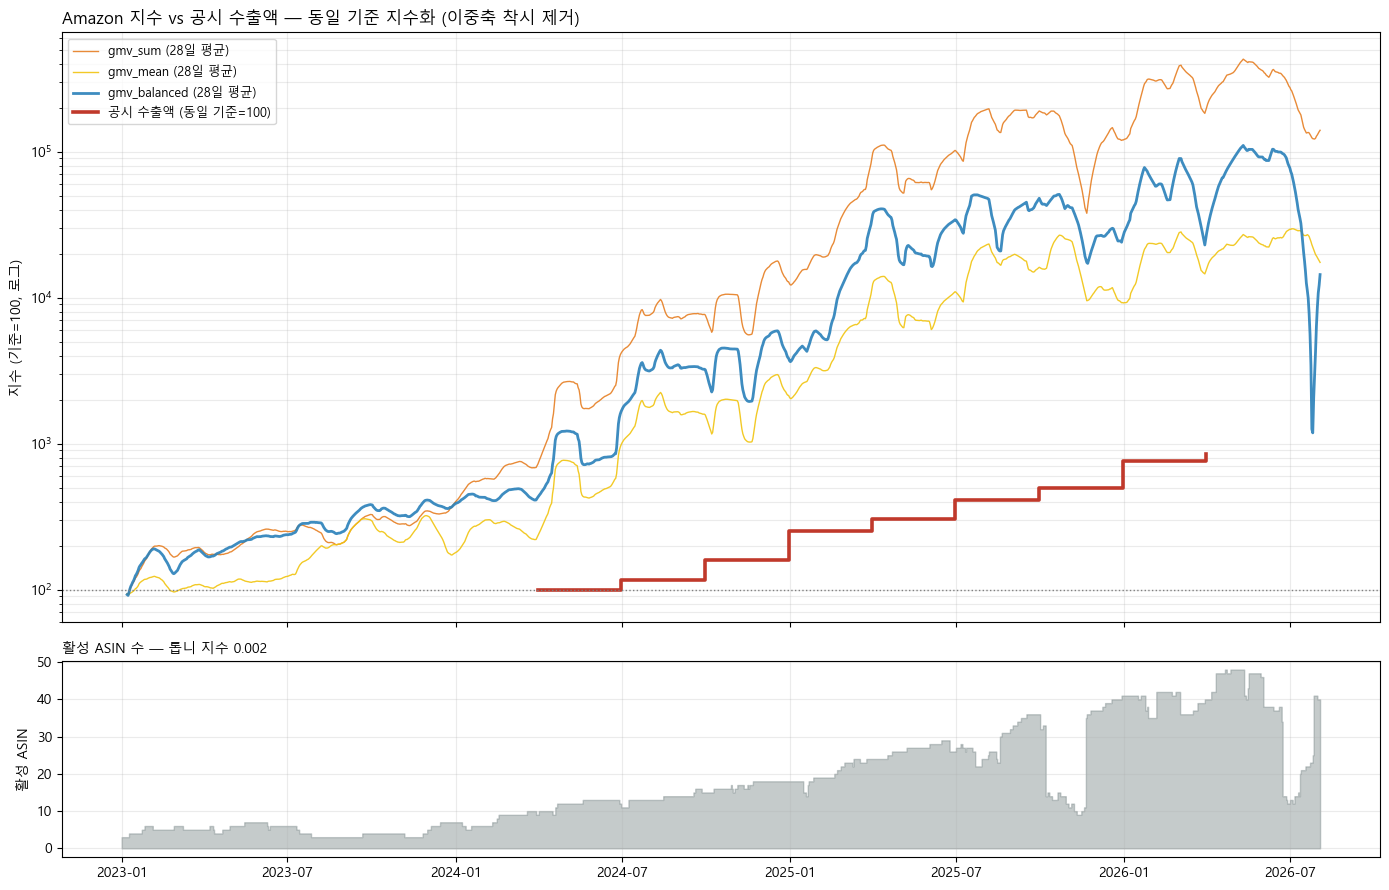

In [16]:
if SHOW_PLOTS and not idx.empty:
    import matplotlib.pyplot as plt

    # 이중축 대신 양쪽 모두 지수화(기준=100) — 스케일 착시 제거
    base_dt = pd.to_datetime(REBASE_DATE) if REBASE_DATE else ANALYSIS_START

    def rb(s):
        s = s.astype(float)
        a = s.loc[s.index >= base_dt].dropna()
        return s / a.iloc[0] * 100 if len(a) and a.iloc[0] else s

    fig, axes = plt.subplots(2, 1, figsize=(FIG_W, 9), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1]})

    ax = axes[0]
    for c, lbl, col, lw in [("gmv_sum", "gmv_sum", "#e67e22", 1.0),
                            ("gmv_mean", "gmv_mean", "#f1c40f", 1.0),
                            ("gmv_balanced", "gmv_balanced", "#2980b9", 2.0)]:
        if c in idx.columns and idx[c].notna().sum():
            ax.plot(idx.index, rb(idx[c]).rolling(28, min_periods=7).mean(),
                    color=col, linewidth=lw, label="%s (28일 평균)" % lbl, alpha=0.9)

    rr = rev.dropna(subset=["export"]).copy()
    rr = rr[rr["q_end"] >= base_dt]
    if len(rr):
        e = rr.set_index("q_end")["export"]
        ax.step(e.index, e / e.iloc[0] * 100, where="post",
                color="#c0392b", linewidth=2.6, label="공시 수출액 (동일 기준=100)")

    ax.set_yscale("log")
    ax.axhline(100, color="grey", linestyle=":", linewidth=1)
    ax.set_ylabel("지수 (기준=100, 로그)")
    ax.set_title("Amazon 지수 vs 공시 수출액 — 동일 기준 지수화 (이중축 착시 제거)",
                 fontsize=12, loc="left")
    ax.legend(fontsize=9); ax.grid(alpha=0.25, which="both")

    ax = axes[1]
    ax.fill_between(idx.index, idx["n_active"], color="#7f8c8d", alpha=0.45, step="post")
    ax.set_ylabel("활성 ASIN")
    ax.set_title("활성 ASIN 수 — 톱니 지수 %.3f" % JAG, fontsize=10, loc="left")
    ax.grid(alpha=0.25)

    plt.tight_layout(); plt.show()


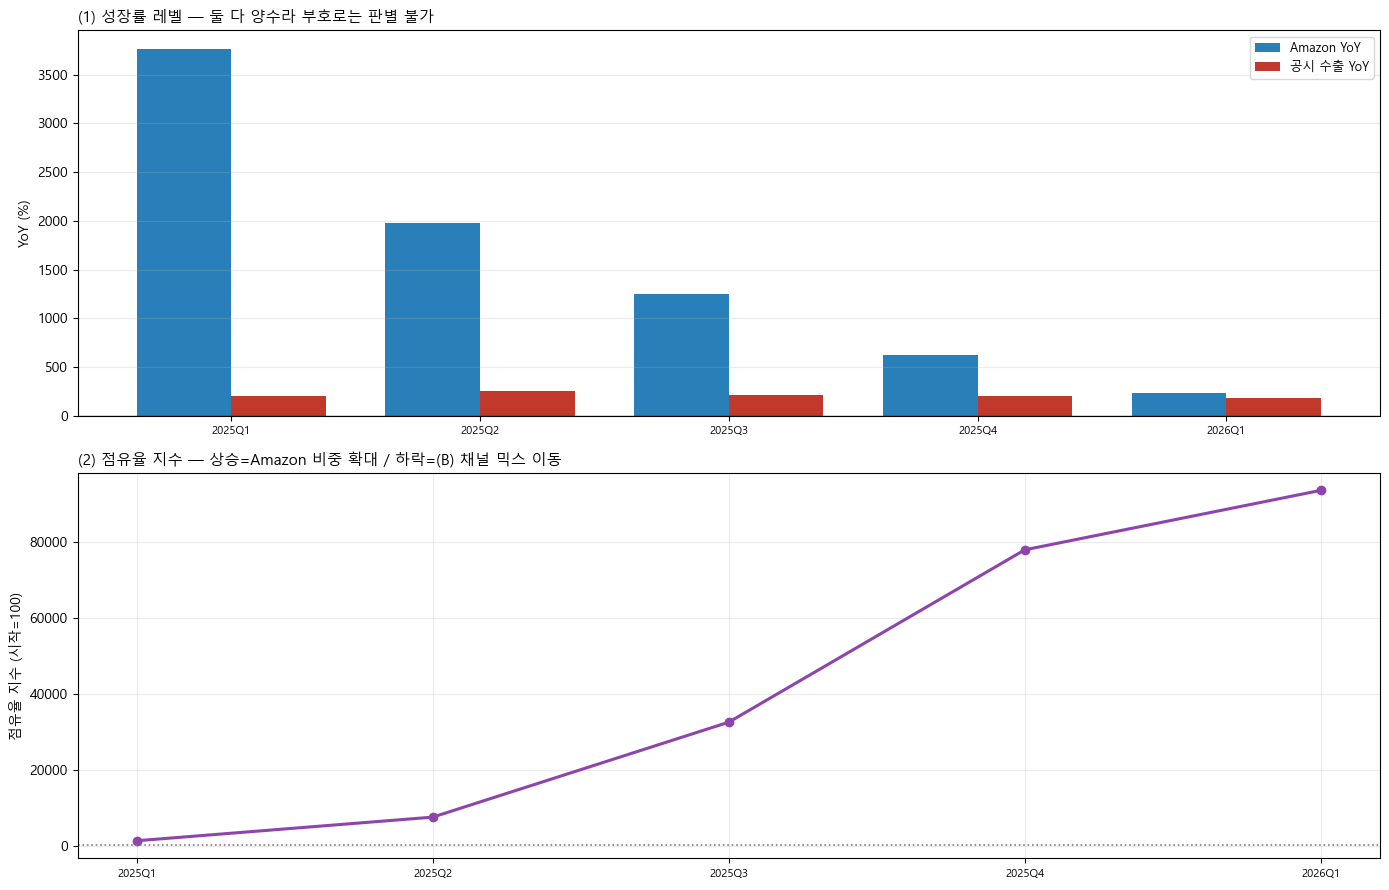

In [17]:
if SHOW_PLOTS and len(share) >= 2:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 1, figsize=(FIG_W, 9))

    xs = np.arange(len(share))
    w = 0.38
    ax = axes[0]
    ax.bar(xs - w / 2, share["amazon_yoy"] * 100, w, label="Amazon YoY", color="#2980b9")
    ax.bar(xs + w / 2, share["export_yoy"] * 100, w, label="공시 수출 YoY", color="#c0392b")
    ax.axhline(0, color="black", linewidth=0.9)
    ax.set_xticks(xs); ax.set_xticklabels(share["label"], fontsize=8)
    ax.set_ylabel("YoY (%)")
    ax.set_title("(1) 성장률 레벨 — 둘 다 양수라 부호로는 판별 불가",
                 fontsize=11, loc="left")
    ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")

    ax = axes[1]
    ax.plot(xs, share["share_index"], marker="o", color="#8e44ad", linewidth=2.2)
    ax.axhline(100, color="grey", linestyle=":", linewidth=1.2)
    ax.set_xticks(xs); ax.set_xticklabels(share["label"], fontsize=8)
    ax.set_ylabel("점유율 지수 (시작=100)")
    ax.set_title("(2) 점유율 지수 — 상승=Amazon 비중 확대 / 하락=(B) 채널 믹스 이동",
                 fontsize=11, loc="left")
    ax.grid(alpha=0.25)

    plt.tight_layout(); plt.show()


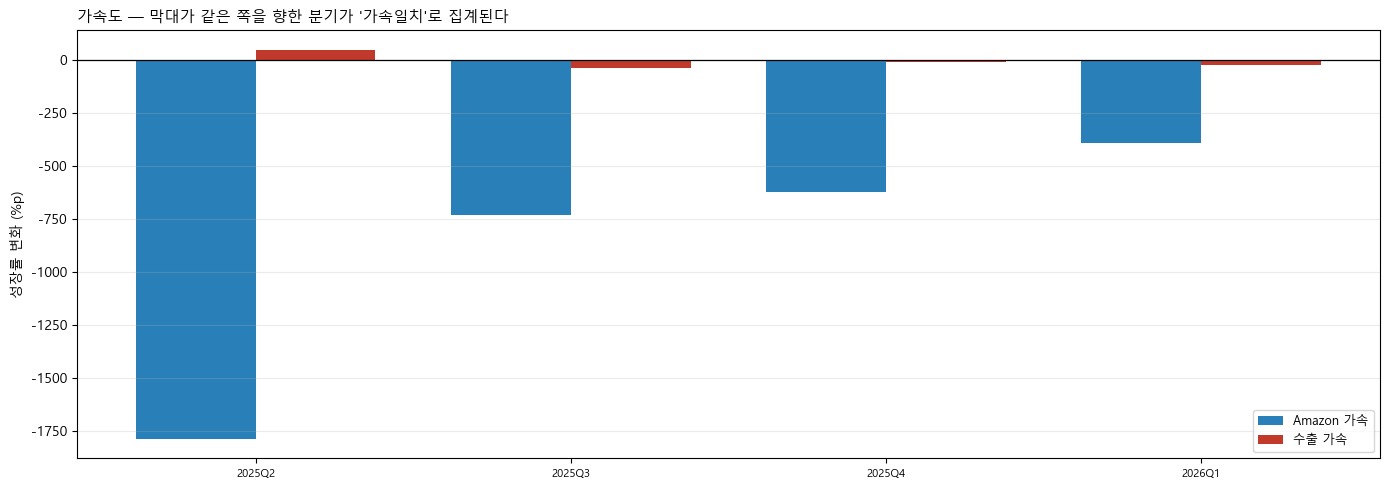

        Amazon가속  수출가속 일치
2025Q2   -1786.0  47.3  X
2025Q3    -731.4 -40.8  O
2025Q4    -624.4  -8.4  O
2026Q1    -390.6 -23.8  O

  어느 분기가 틀렸는지가 일치율 자체보다 중요합니다.
  최근 분기만 틀렸다면 채널 믹스 변화를 의심하십시오.


In [18]:
if SHOW_PLOTS and len(share) >= 3:
    import matplotlib.pyplot as plt

    acc = share[["amazon_yoy", "export_yoy"]].diff() * 100
    acc = acc.dropna()
    if len(acc) >= 2:
        labels = [qlabel(d) for d in acc.index]
        xs = np.arange(len(acc))
        w = 0.38

        fig, ax = plt.subplots(figsize=(FIG_W, 5))
        ax.bar(xs - w / 2, acc["amazon_yoy"], w, label="Amazon 가속", color="#2980b9")
        ax.bar(xs + w / 2, acc["export_yoy"], w, label="수출 가속", color="#c0392b")
        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel("성장률 변화 (%p)")
        ax.set_title("가속도 — 막대가 같은 쪽을 향한 분기가 '가속일치'로 집계된다",
                     fontsize=11, loc="left")
        ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")
        plt.tight_layout(); plt.show()

        # 주의: DatetimeIndex Series 를 문자열 index 와 함께 넘기면 재색인되어
        #       전부 NaN 이 된다. .values 로 넘겨야 한다.
        chk = pd.DataFrame({
            "Amazon가속": acc["amazon_yoy"].round(1).values,
            "수출가속": acc["export_yoy"].round(1).values,
        }, index=labels)
        chk["일치"] = np.where(np.sign(chk["Amazon가속"]) == np.sign(chk["수출가속"]), "O", "X")
        print(chk.to_string())
        print()
        print("  어느 분기가 틀렸는지가 일치율 자체보다 중요합니다.")
        print("  최근 분기만 틀렸다면 채널 믹스 변화를 의심하십시오.")


## 11. 산업 대비 알파 (선택)

In [19]:
if CUSTOMS_ENABLED and DB_AVAILABLE and CUSTOMS_SQL:
    try:
        ind = pd.read_sql(text(CUSTOMS_SQL), ENGINE)
        ind[CUSTOMS_DATE_COL] = pd.to_datetime(ind[CUSTOMS_DATE_COL])
        iq_ = ind.set_index(CUSTOMS_DATE_COL)[CUSTOMS_VAL_COL].resample(RESAMPLE_RULE).sum()
        iq_.index = pd.DatetimeIndex(iq_.index).normalize()
        rq = rev.set_index("q_end")
        industry = pd.DataFrame({"apr_yoy": rq["export_yoy"],
                                 "industry_yoy": iq_.pct_change(4)}).dropna()
        industry["alpha_pp"] = (industry["apr_yoy"] - industry["industry_yoy"]) * 100
        industry.index = [qlabel(d) for d in industry.index]
        print("=" * 66)
        print("산업 대비 알파 (%p)")
        print("=" * 66)
        s = industry.copy()
        for c in ["apr_yoy", "industry_yoy"]:
            s[c] = s[c].map(lambda x: "%.0f%%" % (x * 100))
        s["alpha_pp"] = s["alpha_pp"].map(lambda x: "%+.0f%%p" % x)
        print(s.to_string())
        print()
        print("  양수 = 산업보다 빠른 성장 (점유율 확대)")
    except Exception as e:
        print("[관세청] 조회 실패:", repr(e)[:200])
else:
    print("[관세청] 비활성. CUSTOMS_ENABLED=True 로 두고 CUSTOMS_SQL 을 채우십시오.")
    print("         예: SELECT date, usd_amt FROM <수출테이블> WHERE hs6 LIKE '3304%'")


[관세청] 비활성. CUSTOMS_ENABLED=True 로 두고 CUSTOMS_SQL 을 채우십시오.
         예: SELECT date, usd_amt FROM <수출테이블> WHERE hs6 LIKE '3304%'


## 12. 요약

In [20]:
print("=" * 78)
print("APR Amazon 지수 — V4 요약")
print("=" * 78)
print("  앵커 : %s" % ANCHOR_SOURCE)
print("         분기 %d개 / 수출 YoY %d개"
      % (len(rev), int(rev["export_yoy"].notna().sum())))
if len(daily):
    print("  패널 : 재보간 %s (limit=%d일) / 톱니 %.3f"
          % ("적용" if REFILL_ENABLED else "미적용", REFILL_LIMIT_D, JAG))
if not idx.empty:
    print("  지수 : %d일 / 균형패널 %d개 / alpha=%.2f"
          % (len(idx), idx.attrs.get("n_balanced", 0), ALPHA))
if len(share):
    si = share["share_index"]
    print("  점유 : 지수 %.1f → %.1f (%+.1f%%)"
          % (si.iloc[0], si.iloc[-1], (si.iloc[-1] / si.iloc[0] - 1) * 100))
print()
print("  판정 : %s" % VERDICT)
for w in VERDICT_WHY:
    print("         · %s" % w)
print()
print("  [원칙]")
print("   1. 근거가 부족하면 '유보'입니다. 기각도 채택도 아닙니다.")
print("   2. 지금까지의 일치율은 전부 사후 대조입니다.")
print("      9장 대기 분기를 기록해두고 다음 공시와 대조해야 예측력이 확인됩니다.")
print("   3. 점유율 지수가 계속 하락하면 Amazon 단독 추적은 성립하지 않습니다.")
print("=" * 78)


APR Amazon 지수 — V4 요약
  앵커 : DART 매출실적(뷰티, 연결기준) 누적 차분
         분기 9개 / 수출 YoY 5개
  패널 : 재보간 적용 (limit=21일) / 톱니 0.002
  지수 : 1311일 / 균형패널 4개 / alpha=0.70
  점유 : 지수 1269.2 → 93753.0 (+7286.5%)

  판정 : 판정 유보
         · 가속 관측치 4개 < 기준 6개
         · 균형패널 4개 < 기준 8개

  [원칙]
   1. 근거가 부족하면 '유보'입니다. 기각도 채택도 아닙니다.
   2. 지금까지의 일치율은 전부 사후 대조입니다.
      9장 대기 분기를 기록해두고 다음 공시와 대조해야 예측력이 확인됩니다.
   3. 점유율 지수가 계속 하락하면 Amazon 단독 추적은 성립하지 않습니다.


---

## 다음 행동

1. **`REFILL_LIMIT_D` 조정** — 4장 그리드에서 톱니가 가장 낮고 보간비율 60% 이하인
   값을 고른다. 재수집 불필요.
2. **9장 대기 분기 표를 기록** — 2026Q2 반기보고서가 나오기 전에 남겨둔다.
   사후 대조와 사전 예측은 증거로서의 무게가 다르다.
3. **2026Q2 누적 수출액 추가** — `CUM_EXPORT` 에 한 줄. 그것으로 (A)/(B)가 갈린다.
4. **Trends 노트북 병행** — Amazon과 검색이 같이 꺾였는지 따로 움직였는지가
   (A)/(B) 판별의 독립적 근거가 된다. 무료다.

## 판정 가드레일을 넣은 이유

V3.1은 균형패널 3개, 가속 관측치 4개로 "신호로 사용 가능"을 출력했다.
숫자만 보면 100%지만, **동전 던지기로 4연속 맞을 확률이 6%다.**

근거가 부족한데 확신을 출력하는 도구는 없느니만 못하다.
V4는 기준 미달이면 결과와 무관하게 "유보"를 강제한다.

| 가드레일 | 기본값 | 의미 |
|---|---|---|
| `MIN_ACC_OBS` | 6 | 가속 관측치 |
| `MIN_BALANCED_N` | 8 | 균형패널 ASIN 수 |
| `MAX_JAGGEDNESS` | 0.12 | 활성 ASIN 변동 강도 |

---
*V4 · 2026-08 · 짝 노트북: `apr_us_amazon_keepa_v2`, `apr_us_google_trends_v2`*